<a href="https://colab.research.google.com/github/AdamHopkinss/DD2365/blob/main/Modular_Euler_equations_compressible_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Euler equations for compressible flow**
**Johan Hoffman**

# **Abstract**

This short report show an example on how to use FEniCS to solve the Euler equations using FEM, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://www.kth.se/social/course/DD2365/)

# **About the code**

In [ ]:
# This program is an example file for the course
# DD2365 Advanced Computation in Fluid Mechanics,
# KTH Royal Institute of Technology, Stockholm, Sweden,

# Copyright (C) 2021 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License v2.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

# **Set up environment**

In [ ]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

The Euler equations take the form

$
\begin{eqnarray}
\dot \rho + \nabla \cdot (u \rho) = 0, \\
\dot m + \nabla \cdot (u m) + \nabla p = f, \\
\dot E + \nabla \cdot (u E) + \nabla \cdot(up)= 0,
\end{eqnarray}
$

together with suitable initial and boundary conditions.

Here velocity is given by

$u = \frac{m}{\rho},$

and for a perfect gas, the pressure is given by

$p = (\gamma - 1)(E-\frac{\vert u\vert^2}{2}),$

where $\gamma = 1.4$ is the specific heat ratio for air, and we get the temperature,

$T = \frac{E}{\rho} - \frac{\vert u\vert^2}{2},$

the speed of sound,

$\sqrt{\gamma(\gamma-1)T},$

and the Mach number,

$M = \frac{\vert u\vert }{c}.$

Here we present a FEniCS implementation of a stabilized finite element method to solve the Euler equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

# **Method**

**Define domain and mesh**

In [ ]:
from dolfin import *
import matplotlib.pyplot as plt
import numpy as np

def make_domain_and_boundaries(L=15.0, H=10.0, rc=0.9, resolution=32, refine_levels=1, plot_mesh=False):
    xc = 0.4 * L
    yc = 0.5 * H

    # Create base mesh with a circular hole
    base_geometry = Rectangle(Point(0.0, 0.0), Point(L, H)) - Circle(Point(xc, yc), rc)
    mesh = generate_mesh(base_geometry, resolution)

    # Optional local refinement near the obstacle
    for _ in range(refine_levels):
        cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
        for cell in cells(mesh):
            cell_marker[cell] = cell.midpoint().distance(Point(xc, yc)) < 2 * rc
        mesh = refine(mesh, cell_marker)

    # Define boundary subdomains
    class Left(SubDomain):
        def inside(self, x, on_boundary): return near(x[0], 0.0)

    class Right(SubDomain):
        def inside(self, x, on_boundary): return near(x[0], L)

    class Lower(SubDomain):
        def inside(self, x, on_boundary): return near(x[1], 0.0)

    class Upper(SubDomain):
        def inside(self, x, on_boundary): return near(x[1], H)

    class Object(SubDomain):
        def inside(self, x, on_boundary): return on_boundary and not (
            near(x[0], 0.0) or near(x[0], L) or near(x[1], 0.0) or near(x[1], H)
        )

    # Mark boundaries
    boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
    boundaries.set_all(0)
    Left().mark(boundaries, 1)
    Right().mark(boundaries, 2)
    Lower().mark(boundaries, 3)
    Upper().mark(boundaries, 4)
    Object().mark(boundaries, 5)

    # Define integration measure
    ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

    # Optional mesh plot
    if plot_mesh:
        plt.figure()
        plot(mesh)
        plt.title("Generated mesh with obstacle")
        plt.show()

    return mesh, boundaries, ds, rc, xc, yc


**Define finite element approximation spaces**

In [ ]:
def make_function_spaces(mesh):
    # Generate finite element spaces (for density, momentum, total energy)
    R = FunctionSpace(mesh, "Lagrange", 1)
    V = VectorFunctionSpace(mesh, "Lagrange", 1)
    Q = FunctionSpace(mesh, "Lagrange", 1)

    # Define trial and test functions
    r = TrialFunction(R)
    m = TrialFunction(V)
    E = TrialFunction(Q)
    d = TestFunction(R)
    v = TestFunction(V)
    q = TestFunction(Q)

    trial_fcs = [r, m, E]
    test_fcs = [d, v, q]
    return R, V, Q, trial_fcs, test_fcs

## Altitude dependent inflow parameters

In [ ]:

# Material density in kg/m³ (representing meteor compositions)
def make_meteor(rc, material_choice):
  materials = {
      "iron": 7870.0,                      # iron meteor
      "ice": 917.0,                        # pure ice
      "stone": 3500.0,                     # rocky meteor
      "mixed": 0.6 * 7870.0 + 0.4 * 917.0  # 60% iron, 40% ice
  }

  # Select composition
  #material_choice = "iron"
  object_density = materials[material_choice]

  # Assumed depth of the 3D object (m)
  object_depth = 1.0

  # Compute area of the circular object (2D projection)
  object_area = np.pi * rc**2  # m²

  # Compute volume and mass
  object_volume = object_area * object_depth  # m³
  mass_object = object_density * object_volume  # kg

  print(f"Material: {material_choice}, Mass: {mass_object/1000:.2f} tons")
  return mass_object


### U.S. Standard Atmosphere Model (up to 85 km)

The atmospheric inflow conditions are computed using a piecewise approximation of the U.S. Standard Atmosphere 1976. Each layer is defined by a base altitude $h_b$, lapse rate $L_b$, base temperature $T_b$, and base pressure $p_b$.

**Temperature** is computed via:

$$
T(h) = T_b + L_b (h - h_b)
$$

**Pressure** is computed using the barometric formula:

- For gradient layers ($L_b \ne 0$):

$$
p(h) = p_b \left( \frac{T(h)}{T_b} \right)^{-g_0 / (R L_b)}
$$

- For isothermal layers ($L_b = 0$):

$$
p(h) = p_b \exp\left( \frac{-g_0 (h - h_b)}{R T_b} \right)
$$

**Density** is then obtained from the ideal gas law:

$$
\rho(h) = \frac{p(h)}{R T(h)}
$$

**Total energy** per unit volume at altitude $h$ and inflow velocity $u$ is:

$$
E(h, u) = \rho(h) \left( \frac{1}{2} u^2 + \frac{R T(h)}{\gamma - 1} \right)
$$

where:

- $R = 287.05 \, \text{J/(kg·K)}$ is the specific gas constant for air  
- $\gamma = 1.4$ is the specific heat ratio  
- $g_0 = 9.80665 \, \text{m/s}^2$ is standard gravity


In [ ]:

# Atmospheric layers: [Altitude [m], Temperature lapse rate [K/m], Temperature [K], Pressure [Pa]]
# Based on U.S. Standard Atmosphere 1976
atmo_layers = [
    (0,     -0.0065, 288.15, 101325.0),
    (11000,  0.0,    216.65, 22632.1),
    (20000,  0.0010, 216.65, 5474.89),
    (32000,  0.0028, 228.65, 868.019),
    (47000,  0.0,    270.65, 110.906),
    (51000, -0.0028, 270.65, 66.9389),
    (71000, -0.0020, 214.65, 3.95642),
    (84852,  0.0,    186.8673, 0.3734),  # Edge of model (about 85 km)
]


def inflow_temperature(h):
    for i in range(len(atmo_layers) - 1):
        h_b, L_b, T_b, _ = atmo_layers[i]
        h_t = atmo_layers[i+1][0]
        if h >= h_b and h < h_t:
            return T_b + L_b * (h - h_b)
    # If above last layer
    return atmo_layers[-1][2]


def inflow_density(h):
    # Constants
    R_air = 287.05      # J / (kg*K)
    g0 = 9.80665    # m/s^2
    gamma = 1.4
    for i in range(len(atmo_layers) - 1):
        h_b, L_b, T_b, p_b = atmo_layers[i]
        h_t = atmo_layers[i+1][0]
        if h >= h_b and h < h_t:
            if L_b == 0.0:
                # Isothermal layer
                exponent = -g0 * (h - h_b) / (R_air * T_b)
                p = p_b * np.exp(exponent)
            else:
                # Gradient layer
                T = T_b + L_b * (h - h_b)
                exponent = -g0 / (R_air * L_b)
                p = p_b * (T / T_b) ** exponent
            rho = p / (R_air * inflow_temperature(h))
            return rho
    # If above last layer
    T = inflow_temperature(h)
    p = atmo_layers[-1][3] * np.exp(-g0 * (h - atmo_layers[-1][0]) / (R_air * T))
    rho = p / (R_air * T)
    return rho

def inflow_energy(h, v):      # Dependent on inflow velo. and altitude
    # Constants
    R_air = 287.05      # J / (kg*K)
    g0 = 9.80665    # m/s^2
    gamma = 1.4
    rho = inflow_density(h)
    T = inflow_temperature(h)
    return rho * (0.5 * v**2 + R_air * T / (gamma - 1))


**Define boundary conditions**

In [ ]:
from dolfin import *

def make_boundary_conditions(mesh, R, V, Q, ds, inflow_density, inflow_energy,
                             altitude=5000, velocity_in=600.0, L=15.0, H=10.0):

    # Define boundary subdomains
    class DirichletBoundaryLower(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and near(x[1], 0.0)

    class DirichletBoundaryUpper(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and near(x[1], H)

    class DirichletBoundaryLeft(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and near(x[0], 0.0)

    class DirichletBoundaryRight(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and near(x[0], L)

    class DirichletBoundaryObjects(SubDomain):
        def inside(self, x, on_boundary):
          return on_boundary and not (
            near(x[0], 0.0) or near(x[0], L) or near(x[1], 0.0) or near(x[1], H)
        )

    # Instantiate subdomains
    dbc_lower = DirichletBoundaryLower()
    dbc_upper = DirichletBoundaryUpper()
    dbc_left = DirichletBoundaryLeft()
    dbc_right = DirichletBoundaryRight()
    dbc_objects = DirichletBoundaryObjects()

    # Inflow values
    rho_val = inflow_density(altitude)
    m_val = rho_val * velocity_in
    E_val = inflow_energy(altitude, velocity_in)

    r_in = Constant(rho_val)
    m_in = Constant(m_val)
    E_in = Constant(E_val)


    print(f"inflow density: {float(r_in):.3f}, inflow momentum: {float(m_in):.3f}, inflow energy: {float(E_in):.3f}")

    # Boundary conditions
    bcr = [DirichletBC(R, r_in, dbc_left)]
    bcE = [DirichletBC(Q, E_in, dbc_left)]

    bcm = [
        DirichletBC(V.sub(0), m_in, dbc_left),    # inflow momentum x
        DirichletBC(V.sub(1), 0.0, dbc_left),     # inflow momentum y

        # Slip-wall BCs (top/bottom)
        #DirichletBC(V.sub(0), 0.0, dbc_upper),   # x-direction
        DirichletBC(V.sub(1), 0.0, dbc_upper),    # y-direction
        #DirichletBC(V.sub(0), 0.0, dbc_lower),   # x
        DirichletBC(V.sub(1), 0.0, dbc_lower),    # y

        # Uncomment for strong BC enforment on object surface
        # If so, change: + alpha * inner(dot(mm, normal), dot(v, normal)) * ds(5)
        # in variational form (momentum)
        DirichletBC(V.sub(0), 0.0, dbc_objects),
        DirichletBC(V.sub(1), 0.0, dbc_objects),
    ]

    """
        bcr: DirichletBC list for density
        bcm: DirichletBC list for momentum (vector-valued)
        bcE: DirichletBC list for energy
        r_in, m_in, E_in: Constants for inflow, can be updated during simulation
    """

    return bcr, bcm, bcE, r_in, m_in, E_in


# **Results**

**Define method parameters**

In [ ]:
from dolfin import *

def initialize_solver_state(R, V, Q, mesh, r_in, m_in, num_nnlin_iter=5):
    # Previous time step functions
    r0 = Function(R)
    m0 = Function(V)
    E0 = Function(Q)

    # Current linearized step
    r1 = Function(R)
    m1 = Function(V)
    E1 = Function(Q)

    # Small epsilon to avoid division by zero
    eps_cav = 1.0e-6

    # Choose preconditioner based on availability
    prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

    u_in = float(m_in(0) / r_in(0))  # inflow velocity
    dt_val = 0.5 * mesh.hmin() / u_in  # CFL condition: dt: h / u
    dt = Constant(dt_val)


    return r0, m0, E0, r1, m1, E1, dt, eps_cav, num_nnlin_iter, prec


**Define variational problem**

### Adaptive Stabilization Parameters

We scale key stabilization terms with the local Mach number $\mathrm{Ma}$ to improve robustness across flow regimes:

- **SUPG stabilization:**
  $$
  C_1(\mathrm{Ma}) = 0.5 + 4.5 \cdot \frac{\mathrm{Ma}^2}{1 + \mathrm{Ma}^2}
  $$
  Smoothly increases from 0.5 (incompressible) to 5 (hypersonic), used in time/space stabilization.

- **Artificial viscosity:**
  $$
  C_{\text{stab}}(\mathrm{Ma}) = 1 + 39 \cdot \frac{\mathrm{Ma}}{1 + \mathrm{Ma}}
  $$
  Rises from 1 to ~40 to stabilize shocks via residual-based diffusion.

- **Penalty parameter:**
  $$
  C_\alpha(\mathrm{Ma}) = 100 + 800 \cdot \frac{\mathrm{Ma}}{1 + \mathrm{Ma}}
  $$
  Ramps from 100 to 900, strengthening boundary enforcement at higher speeds.


In [ ]:
def define_variational_forms(mesh, ds, R, V, Q,
                             trial_funcs, test_funcs,
                             r0, m0, E0, r1, m1, E1,
                             dt, eps_cav,
                             r_in, m_in, E_in,
                             gamma=1.4):
    # Unpack trial and test functions
    r, m, E = trial_funcs
    d, v, q = test_funcs

    # Time-averaged values
    rm = 0.5 * (r + r0)
    mm = 0.5 * (m + m0)
    Em = 0.5 * (E + E0)

    rm1 = 0.5 * (r1 + r0)
    mm1 = 0.5 * (m1 + m0)
    Em1 = 0.5 * (E1 + E0)

    # Velocity fields
    u0 = m0 / (r0 + eps_cav)
    u1 = m1 / (r1 + eps_cav)
    um1 = 0.5 * (u1 + u0)

    # Pressure and temperature
    p1 = (gamma - 1.0) * (E1 - 0.5 * inner(m1, m1) / (r1 + eps_cav))
    Temp = E1 / (r1 + eps_cav) - 0.5 * inner(u1, u1)

    # Speed of sound and Mach
    c = sqrt(gamma * p1 / (r1 + eps_cav))
    Mach = sqrt(inner(u1, u1)) / (c + eps_cav)
    Mach_number = project(sqrt(inner(u1, u1)) / (c + eps_cav), Q)

    # Mesh and geometry
    h = CellDiameter(mesh)
    normal = FacetNormal(mesh)


    # Adaptive stabilization parameters
    # C1: SUPG-like stabilization factor for time/space weighting.
    # C_stab: Artificial viscosity scaling for shock capturing
    # C_alpha: Penalty factor for weak boundary enforcement (e.g. wall/outflow).
    C1 = 0.5 + 4.5 * Mach_number**2 / (1 + Mach_number**2)     # 0.5 to 5.0
    C_stab = 1 + 39 * Mach_number**2 / (1 + Mach_number**2)    #   5 to 100
    C_alpha = 100 + 800 * Mach_number**2 / (1 + Mach_number**2) # 50 to 800

    d1 = C1 / sqrt(1.0 / dt**2 + dot(u1, u1) / h**2)
    alpha = C_alpha / h


    # Residuals
    res_r = (r1 - r0) / dt + div(r1 * u1)
    res_m = (m1 - m0) / dt + div(u1) * m1 + dot(grad(m1),u1) + grad(p1)
    flux_E = E1 * u1 + p1 * u1
    res_E = (E1 - E0) / dt + div(flux_E)

    # Shock sensor (symbolic version)
    # grad_E1_sq = inner(grad(E1), grad(E1)) + DOLFIN_EPS
    # sensor_E = sqrt(grad_E1_sq) / (E1 + DOLFIN_EPS)
    # sensor_cut = sensor_E / (sensor_E + 1.0)
    sensor_cut = 1.0


    # Artificial viscosity
    nu_r = C_stab * h**2 * sqrt(inner(res_r, res_r) + DOLFIN_EPS) / r_in #* sensor_cut
    nu_m = C_stab * h**2 * sqrt(inner(res_m, res_m) + DOLFIN_EPS) / m_in #* sensor_cut
    nu_E = C_stab * h**2 * sqrt(inner(res_E, res_E) + DOLFIN_EPS) / E_in #* sensor_cut

    #### Variational forms ####

    # Density equation
    Fr = inner((r - r0) / dt, d) * dx \
        - inner(rm * um1, grad(d)) * dx \
        + nu_r * inner(grad(rm), grad(d)) * dx \
        + inner(dot(um1, normal) * r_in, d) * ds(1) \
        + inner(dot(um1, normal) * rm, d) * ds(2) \
        + d1 * inner((r - r0) / dt + div(rm * u1), dot(grad(d), u1)) * dx

    ar, Lr = lhs(Fr), rhs(Fr)

    # Momentum equation
    Fm = inner((m - m0) / dt, v) * dx \
        - inner(outer(mm, um1), grad(v)) * dx \
        - p1 * div(v) * dx \
        + nu_m * inner(grad(mm), grad(v)) * dx \
        + inner(dot(u1, normal) * as_vector([m_in, 0.0]), v) * ds(1) \
        + inner(dot(u1, normal) * mm, v) * ds(2) \
        + d1 * inner((m - m0) / dt + div(outer(mm, u1)) + grad(p1), grad(v) * u1) * dx
        # + alpha * inner(dot(mm, normal), dot(v, normal)) * ds(5)  # Optional wall penalty

    am, Lm = lhs(Fm), rhs(Fm)

    # Energy equation
    FE = inner((E - E0) / dt, q) * dx \
         - inner(Em * um1, grad(q)) * dx \
         + nu_E * inner(grad(Em), grad(q)) * dx \
         + inner(dot(um1, normal) * E_in, q) * ds(1) \
         + inner(dot(um1, normal) * Em, q) * ds(2) \
         + d1 * inner((E - E0) / dt + div(flux_E), dot(grad(q), u1)) * dx

    aE, LE = lhs(FE), rhs(FE)

    return ar, Lr, am, Lm, aE, LE, sensor_cut


**Compute force on boundary**

In [ ]:
def compute_surface_force(mesh, psi_dir, ds, p1, surface_id=5, rc=None, u_in=None):

    V_psi = VectorFunctionSpace(mesh, "CG", 1)
    psi = Function(V_psi)
    psi.vector()[:] = 0.0
    bc_psi = DirichletBC(V_psi, Constant(psi_dir), "on_boundary")
    bc_psi.apply(psi.vector())

    n = FacetNormal(mesh)
    Force_pressure = inner(n, psi) * p1 * ds(surface_id)

    normalization = -2.0 / (2.0 * rc * u_in * u_in)

    return Force_pressure, normalization


**Set plotting variables and open export files**

In [ ]:
# Open files to export solution to Paraview
file_r = File("results-NS/r.pvd")
file_m = File("results-NS/m.pvd")
file_E = File("results-NS/E.pvd")
file_Mach = File("results-NS/Mach.pvd")

# Set plot frequency
plot_time = 0
plot_interval = 0.01

# Force computation data

force_array_pressure = np.array(0.0)
force_array_pressure = np.delete(force_array_pressure, 0)

time = np.array(0.0)
time = np.delete(time, 0)

start_sample_time = 0.05

In [ ]:
def plot_solutions(r1, m1, E1, Q, eps_cav, gamma, t,
                   file_r=None, file_m=None, file_E=None, file_Mach=None):

    u1 = m1 / (r1 + eps_cav)
    Temp = E1 / (r1 + eps_cav) - 0.5 * inner(u1, u1)
    c = sqrt(gamma * (gamma - 1.0) * abs(Temp))
    Mach_number = project(sqrt(inner(u1, u1)) / (c + eps_cav), Q)

    if file_r: file_r << r1
    if file_m: file_m << m1
    if file_E: file_E << E1
    if file_Mach: file_Mach << Mach_number

    print(f"Plotting at time t = {t:.3f}")

    plt.figure(); im = plot(r1, title="Density"); plt.colorbar(im)
    plt.figure(); im = plot(m1, title="Momentum"); plt.colorbar(im)
    plt.figure(); im = plot(E1, title="Total energy"); plt.colorbar(im)
    plt.figure(); im = plot(u1, title="Velocity"); plt.colorbar(im)
    plt.figure(); im = plot(sqrt(inner(u1, u1)), title="Velocity magnitude"); plt.colorbar(im)
    plt.figure(); im = plot(Mach_number, title="Mach number"); plt.colorbar(im)
    plt.figure(); im = plot(Temp, title="Temperature"); plt.colorbar(im)

    plt.show()


**Time stepping algorithm**

In [ ]:
# Debug function and classes
def verify_state(r, m, E, eps=1e-6, threshold=1e6):
    r_vals = r.vector().get_local()
    m_vals = m.vector().get_local()
    E_vals = E.vector().get_local()

    if np.any(np.isnan(r_vals)) or np.any(r_vals < eps):
        raise SimulationFailure("r1 contains NaN or too small values")

    if np.any(np.isnan(m_vals)) or np.any(np.abs(m_vals) > threshold):
        raise SimulationFailure("m1 contains NaN or extreme values")

    if np.any(np.isnan(E_vals)) or np.any(E_vals < eps):
        raise SimulationFailure("E1 contains NaN or too small values")

class SimulationFailure(Exception):
    pass

def update_inflow_conditions(altitude, velocity, r_in, m_in, E_in, inflow_density, inflow_energy):
    rho = inflow_density(altitude)
    E = inflow_energy(altitude, velocity)
    r_in.assign(rho)
    m_in.assign(rho * velocity)
    E_in.assign(E)

# Solves one time step
def solve_one_time_step(r0, r1, m0, m1, E0, E1, dt, eps_cav,
                        ar, Lr, am, Lm, aE, LE,
                        bcr, bcm, bcE, num_nnlin_iter, Force_pressure,
                        force_array_pressure, time, t, normalization, gamma,
                        start_sample_time = 0.05):
    relax = 0.5   # stabilize Newton iterations
    for k in range(num_nnlin_iter):

        r_prev = r1.copy(deepcopy=True)
        m_prev = m1.copy(deepcopy=True)
        E_prev = E1.copy(deepcopy=True)

        # Debug
        # Check for NaNs before momentum solve
        verify_state(r1, m1, E1)

        try:
            #print("  Solving for density...")
            solve(assemble(ar), r1.vector(), assemble(Lr), "bicgstab", "default")
            [bc.apply(r1.vector()) for bc in bcr]
        except RuntimeError as e:
            raise SimulationFailure(f"[SOLVER FAILED] Density solve failed at Newton iteration {k+1}\n    Reason: {e}")
        try:
            print("  Assembling momentum matrix...")

            # Debug velocity u1
            V_u = m1.function_space()
            u1_proj = project(m1 / (r1 + eps_cav), V_u)
            u1_vals = u1_proj.vector().get_local()
            if np.any(np.isnan(u1_vals)) or np.any(np.abs(u1_vals) > 1e6):
                raise SimulationFailure("u1 has NaNs or extreme values before assembling am")

            # Debug pressure p1
            r_vals = r1.vector().get_local()
            m_vals = m1.vector().get_local()
            E_vals = E1.vector().get_local()
            p_vec = (gamma - 1.0) * (E_vals - 0.5 * np.sum(m_vals**2) / (r_vals + eps_cav))
            if np.any(np.isnan(p_vec)) or np.any(np.abs(p_vec) > 1e12):
                raise SimulationFailure("p1 has NaNs or extreme values before assembling am")

        except SimulationFailure as e:
            print("[DEBUG FAILURE] " + str(e))
            raise
        # Avoid unphysical values (negative density) locally
        r1.vector().set_local(np.maximum(r1.vector().get_local(), 1e-6))
        try:
            #print("  Solving for momentum...")
            A_momentum = assemble(am)
            print(f"Condition number estimate: {A_momentum.norm('fro')}")
            solve(assemble(am), m1.vector(), assemble(Lm), "bicgstab", "default")
            [bc.apply(m1.vector()) for bc in bcm]
        except RuntimeError as e:
            raise SimulationFailure(f"[SOLVER FAILED] Momentum solve failed at Newton iteration {k+1}\n    Reason: {e}")

        # Compute pressure
        #print("  Computing pressure...")
        p_vec = (gamma - 1.0) * (E1.vector().get_local() - 0.5 * np.sum(m1.vector().get_local()**2) / (r1.vector().get_local() + eps_cav))
        if np.any(np.isnan(p_vec)) or np.any(np.abs(p_vec) > 1e12):
          idx = np.argmax(np.abs(p_vec))
          E_vec = E1.vector().get_local()
          m_vec = m1.vector().get_local()
          r_vec = r1.vector().get_local()
          raise SimulationFailure(f"[PRESSURE PROBLEM] Pressure explosion or NaN detected before energy solve\n"
                                  f"  max(abs(Pressure)) = {p_vec[idx]:.3e}\n"
                                  f"  Momentum (at max p) = {m_vec[idx]:.3e}\n"
                                  f"  Energy (at max p) = {E_vec[idx]:.3e}"
                                  f"  Density (at max p) = {r_vec[idx]:.3e}")

        # Solve for energy
        try:
            #print("  Solving for energy...")
            solve(assemble(aE), E1.vector(), assemble(LE), "bicgstab", "default")
            [bc.apply(E1.vector()) for bc in bcE]
        except RuntimeError as e:
            raise SimulationFailure(f"[SOLVER FAILED] Energy solve failed at Newton iteration {k+1}\n     Reason: {e}")
        # Avoid unphysical values (negative Energy) locally
        E1.vector().set_local(np.maximum(E1.vector().get_local(), 1e-6))

        # Under-relaxation
        r1.vector()[:] = (1 - relax) * r_prev.vector()[:] + relax * r1.vector()[:]
        m1.vector()[:] = (1 - relax) * m_prev.vector()[:] + relax * m1.vector()[:]
        E1.vector()[:] = (1 - relax) * E_prev.vector()[:] + relax * E1.vector()[:]

    # Compute forces
    if t > start_sample_time:
        Fp = assemble(Force_pressure)
        force_array_pressure.append(normalization * Fp)
        time.append(t)



In [ ]:
def update_dt(velocity, mesh, CFL=0.1):
    velocity = abs(velocity)
    if velocity < 1e-8:
        velocity = 1e-8
    return float(CFL * mesh.hmin() / velocity)

# Update altitude, and velocity of projectile
def update_physics(mass_object, g0, D, velocity, altitude, dt):
    acceleration = (mass_object * g0 - D) / mass_object
    velocity += acceleration * dt
    altitude -= velocity * dt + 0.5 * acceleration * dt**2
    return velocity, altitude

def run_simulation_loop(
    altitude, velocity, mesh, r_in, m_in, E_in,
    inflow_density, inflow_energy,
    trial_funcs, test_funcs,
    r0, r1, m0, m1, E0, E1,
    ar, Lr, am, Lm, aE, LE,
    bcr, bcm, bcE, Force_pressure, normalization, force_array_pressure, time, Q,
    eps_cav, gamma, mass_object, g0, num_nnlin_iter=5, plot_interval=0.05,
    start_sample_time=0.1):
    t = 0.0
    plot_time = 0.0
    while altitude > (altitude - 100):  # Simulate for 100 m
        update_inflow_conditions(altitude, velocity, r_in, m_in, E_in, inflow_density, inflow_energy)
        dt.assign(update_dt(velocity, mesh))

        ar, Lr, am, Lm, aE, LE, sensor_cut = define_variational_forms(mesh, ds, R, V, Q,
                             trial_funcs, test_funcs,
                             r0, m0, E0, r1, m1, E1,
                             dt, eps_cav,
                             r_in, m_in, E_in,
                             gamma=1.4)
        solve_one_time_step(r0, r1, m0, m1, E0, E1, dt, eps_cav,
                        ar, Lr, am, Lm, aE, LE,
                        bcr, bcm, bcE, num_nnlin_iter, Force_pressure,
                        force_array_pressure, time, t, normalization, gamma,
                        start_sample_time = 0.05)

        if t > plot_time:
            plot_solutions(r1, m1, E1, Q, eps_cav, gamma, t,
                           file_r, file_m, file_E, file_Mach)
            plot_time += plot_interval

        D = float(assemble(Force_pressure))
        velocity, altitude = update_physics(mass_object, g0, D, velocity, altitude, float(dt))

        r0.assign(r1)
        m0.assign(m1)
        E0.assign(E1)

        t += float(dt)


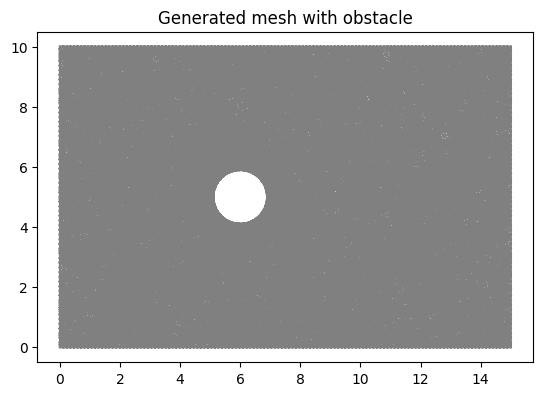

Material: iron, Mass: 20.03 tons
inflow density: 0.413, inflow momentum: 412.705, inflow energy: 272442.086
Min/max initial r0: 0.4127047353692698 0.4127047353692698
Min/max initial m0: 0.0 412.7047353692698
Min/max initial E0: 272442.08633541287 272442.08633541287
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_41733aa88767c5932f8bf6c1aeb9fb3a2baca94f

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    3
  Coefficients:              '[f_61, f_64, f_67]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 13
INFO:FFC:  quadrature_degree: 13
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.118288 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-----------------

Couldn't map 'f_92' to a float, returning ufl object without evaluation.


Couldn't map 'f_92' to a float, returning ufl object without evaluation.


Couldn't map 'f_92' to a float, returning ufl object without evaluation.


...

Couldn't map 'f_92' to a float, returning ufl object without evaluation.


Couldn't map 'f_92' to a float, returning ufl object without evaluation.


Couldn't map 'f_92' to a float, returning ufl object without evaluation.


Couldn't map 'f_92' to a float, returning ufl object without evaluation.



KeyboardInterrupt



In [ ]:
# Starting velocity and altitude
velocity_in = 1000
altitude_start = 10000.0
material_choice = "iron"    # iron, ice, stone, mixed

# Mesh
mesh, boundaries, ds, rc, xc, yc = make_domain_and_boundaries(
    L=15.0, H=10.0, rc=0.9, resolution=96, refine_levels=1, plot_mesh=True
)
# Define projectile (meteor)
mass_object = make_meteor(rc, material_choice)

# Functions Spaces
R, V, Q, (r, m, E), (d, v, q) = make_function_spaces(mesh)

# Boundary conditions
bcr, bcm, bcE, r_in, m_in, E_in = make_boundary_conditions(
    mesh, R, V, Q, ds,
    inflow_density=inflow_density,
    inflow_energy=inflow_energy,
    altitude=altitude_start,
    velocity_in=velocity_in,
    L=15.0,
    H=10.0
)

# Initialize the state
r0, m0, E0, r1, m1, E1, dt, eps_cav, num_nnlin_iter, prec = initialize_solver_state(
    R, V, Q, mesh, r_in, m_in
)

r0.interpolate(Constant(r_in))
m0.interpolate(Constant((m_in, 0.0)))
E0.interpolate(Constant(E_in))

print("Min/max initial r0:", r0.vector().min(), r0.vector().max())
print("Min/max initial m0:", m0.vector().min(), m0.vector().max())
print("Min/max initial E0:", E0.vector().min(), E0.vector().max())

r1.assign(r0)
m1.assign(m0)
E1.assign(E0)

# Variational form and shock sensor
ar, Lr, am, Lm, aE, LE, sensor_cut = define_variational_forms(
    mesh, ds, R, V, Q,
    (r, m, E), (d, v, q),
    r0, m0, E0, r1, m1, E1,
    dt, eps_cav,
    r_in, m_in, E_in,
    gamma=1.4
)

# Perfect gas
gamma = 1.4

# Pressure
p1 = (gamma - 1.0)*(E1 - 0.5*inner(m1,m1)/(r1 + eps_cav)) # pressure
# Force
Force_pressure, normalization = compute_surface_force(
    mesh, Constant((1.0, 0.0)), ds, p1, surface_id=5, rc=rc, u_in=velocity_in
)

# Run simulation
run_simulation_loop(
    altitude=altitude_start,
    velocity=velocity_in,
    mesh=mesh,
    r_in=r_in,
    m_in=m_in,
    E_in=E_in,
    inflow_density=inflow_density,
    inflow_energy=inflow_energy,
    trial_funcs = (r, m, E),
    test_funcs = (d, v, q),
    r0=r0, r1=r1,
    m0=m0, m1=m1,
    E0=E0, E1=E1,
    ar=ar, Lr=Lr,
    am=am, Lm=Lm,
    aE=aE, LE=LE,
    bcr=bcr, bcm=bcm, bcE=bcE,
    Force_pressure=Force_pressure,
    normalization=normalization,
    force_array_pressure=force_array_pressure,
    time=time,
    Q=Q,
    eps_cav=eps_cav,
    gamma=1.4,
    mass_object=make_meteor(rc),
    g0=9.80665,
    num_nnlin_iter=num_nnlin_iter,
    plot_interval=0.01,
    start_sample_time=0.05
)

# Plot drag coefficient
plt.figure()
plt.title("Pressure drag coefficient")
plt.plot(time, force_array_pressure)
plt.xlabel("Time [s]")
plt.ylabel("C_d")
plt.grid()
plt.show()


# **Discussion**

A stabilized finite element method was implemented in FEniCS to solve the Euler equations for compressible flow in 2D.